# 05 — Step-by-Step Integration and Live Diagnostics

Use `init` / `step!` / `solve!` on the canonical 2D Kepler problem with `:lifted_pair` regularization, and watch the `RegularizationDiagnostics` evolve live. This is the way to confirm, concretely, what backends and modes are firing around periapsis.

**`mode_history` encoding** (see [`theory/RegularizedIntegrationDesign.md`](../../../theory/RegularizedIntegrationDesign.md)):

- `0` — unregularized Cartesian step
- `1` — pair regularization active (2 particles in component)
- `2` — chain regularization active (>2 particles in component)

In [1]:
include(joinpath(@__DIR__, "common.jl"))

## 1. Build and initialize

In [2]:
prob = canonical_2d_problem(
    regularization = RegularizationOptions(
        enabled = true, backend = :lifted_pair, r_on = 0.5, r_off = 0.7, max_substeps = 256,
    ),
)

integrator = init(prob)
println("Requested backend: ", integrator.diagnostics.requested_backend)
println("Used backend:      ", integrator.diagnostics.used_backend)

Requested backend: lifted_pair
Used backend:      disabled

Used backend:      disabled


## 2. Step 2000 times, reporting every 200 steps

The first periapsis passage is around $t \approx T/2 \approx 2.7$, i.e. step $\approx 2700$ at `dt = 0.001`. We'll step part of the way and watch the mode transitions.

In [3]:
mode_snapshots = Int[]
for k in 1:2000
    step!(integrator)
    if k % 200 == 0
        d = integrator.diagnostics
        @printf("step %4d  t = %7.4f  mode = %d  pair = %4d  lifted = %4d  max_cv = %.2e\n",
            k, integrator.t, d.mode_history[k], d.pair_steps, d.lifted_pair_steps, d.max_constraint_violation)
    end
end

step  200  t =  0.2000  mode = 0  pair =    0  lifted =    0  max_cv = 0.00e+00
step  400  t =  0.4000  mode = 0  pair =    0  lifted =    0  max_cv = 0.00e+00
step  600  t =  0.6000  mode = 0  pair =    0  lifted =    0  max_cv = 0.00e+00
step  800  t =  0.8000  mode = 0  pair =    0  lifted =    0  max_cv = 0.00e+00
step 1000  t =  1.0000  mode = 0  pair =    0  lifted =    0  max_cv = 0.00e+00
step 1200  t =  1.2000  mode = 0  pair =    0  lifted =    0  max_cv = 0.00e+00
step 1400  t =  1.4000  mode = 0  pair =    0  lifted =    0  max_cv = 0.00e+00
step 1600  t =  1.6000  mode = 0  pair =    0  lifted =    0  max_cv = 0.00e+00
step 1800  t =  1.8000  mode = 0  pair =    0  lifted =    0  max_cv = 0.00e+00
step 2000  t =  2.0000  mode = 0  pair =    0  lifted =    0  max_cv = 0.00e+00
step  600  t =  0.6000  mode = 0  pair =    0  lifted =    0  max_cv = 0.00e+00
step  800  t =  0.8000  mode = 0  pair =    0  lifted =    0  max_cv = 0.00e+00
step 1000  t =  1.0000  mode = 0  pair =

## 3. Finish the integration and inspect mode history

In [4]:
sol = solve!(integrator)
print_reg_diagnostics(sol; label = "stepped")

mode_hist = sol.regularization.mode_history
println()
println("Total steps: ", length(mode_hist))
println("  mode 0 (unregularized): ", count(==(UInt8(0)), mode_hist))
println("  mode 1 (pair):          ", count(==(UInt8(1)), mode_hist))
println("  mode 2 (chain):         ", count(==(UInt8(2)), mode_hist))

[stepped] retcode                  = Success
[stepped] requested_backend        = lifted_pair
[stepped] used_backend             = lifted_pair
[stepped] active_steps             = 2311
[stepped] pair_steps               = 2311
[stepped] adaptive_pair_steps      = 0
[stepped] lifted_pair_steps        = 2311
[stepped] chain_steps              = 0
[stepped] unregularized_steps      = 24830
[stepped] backend_fallback_steps   = 0
[stepped] total_substeps           = 30382
[stepped] max_substeps_used        = 3
[stepped] activation_count         = 5
[stepped] deactivation_count       = 5
[stepped] min_encounter_distance   = 0.285714
[stepped] max_constraint_violation = 0.000e+00

Total steps: 27141
  mode 0 (unregularized): 24830
  mode 1 (pair):          2311
  mode 2 (chain):         0


## 4. Final plots from the stepped solution

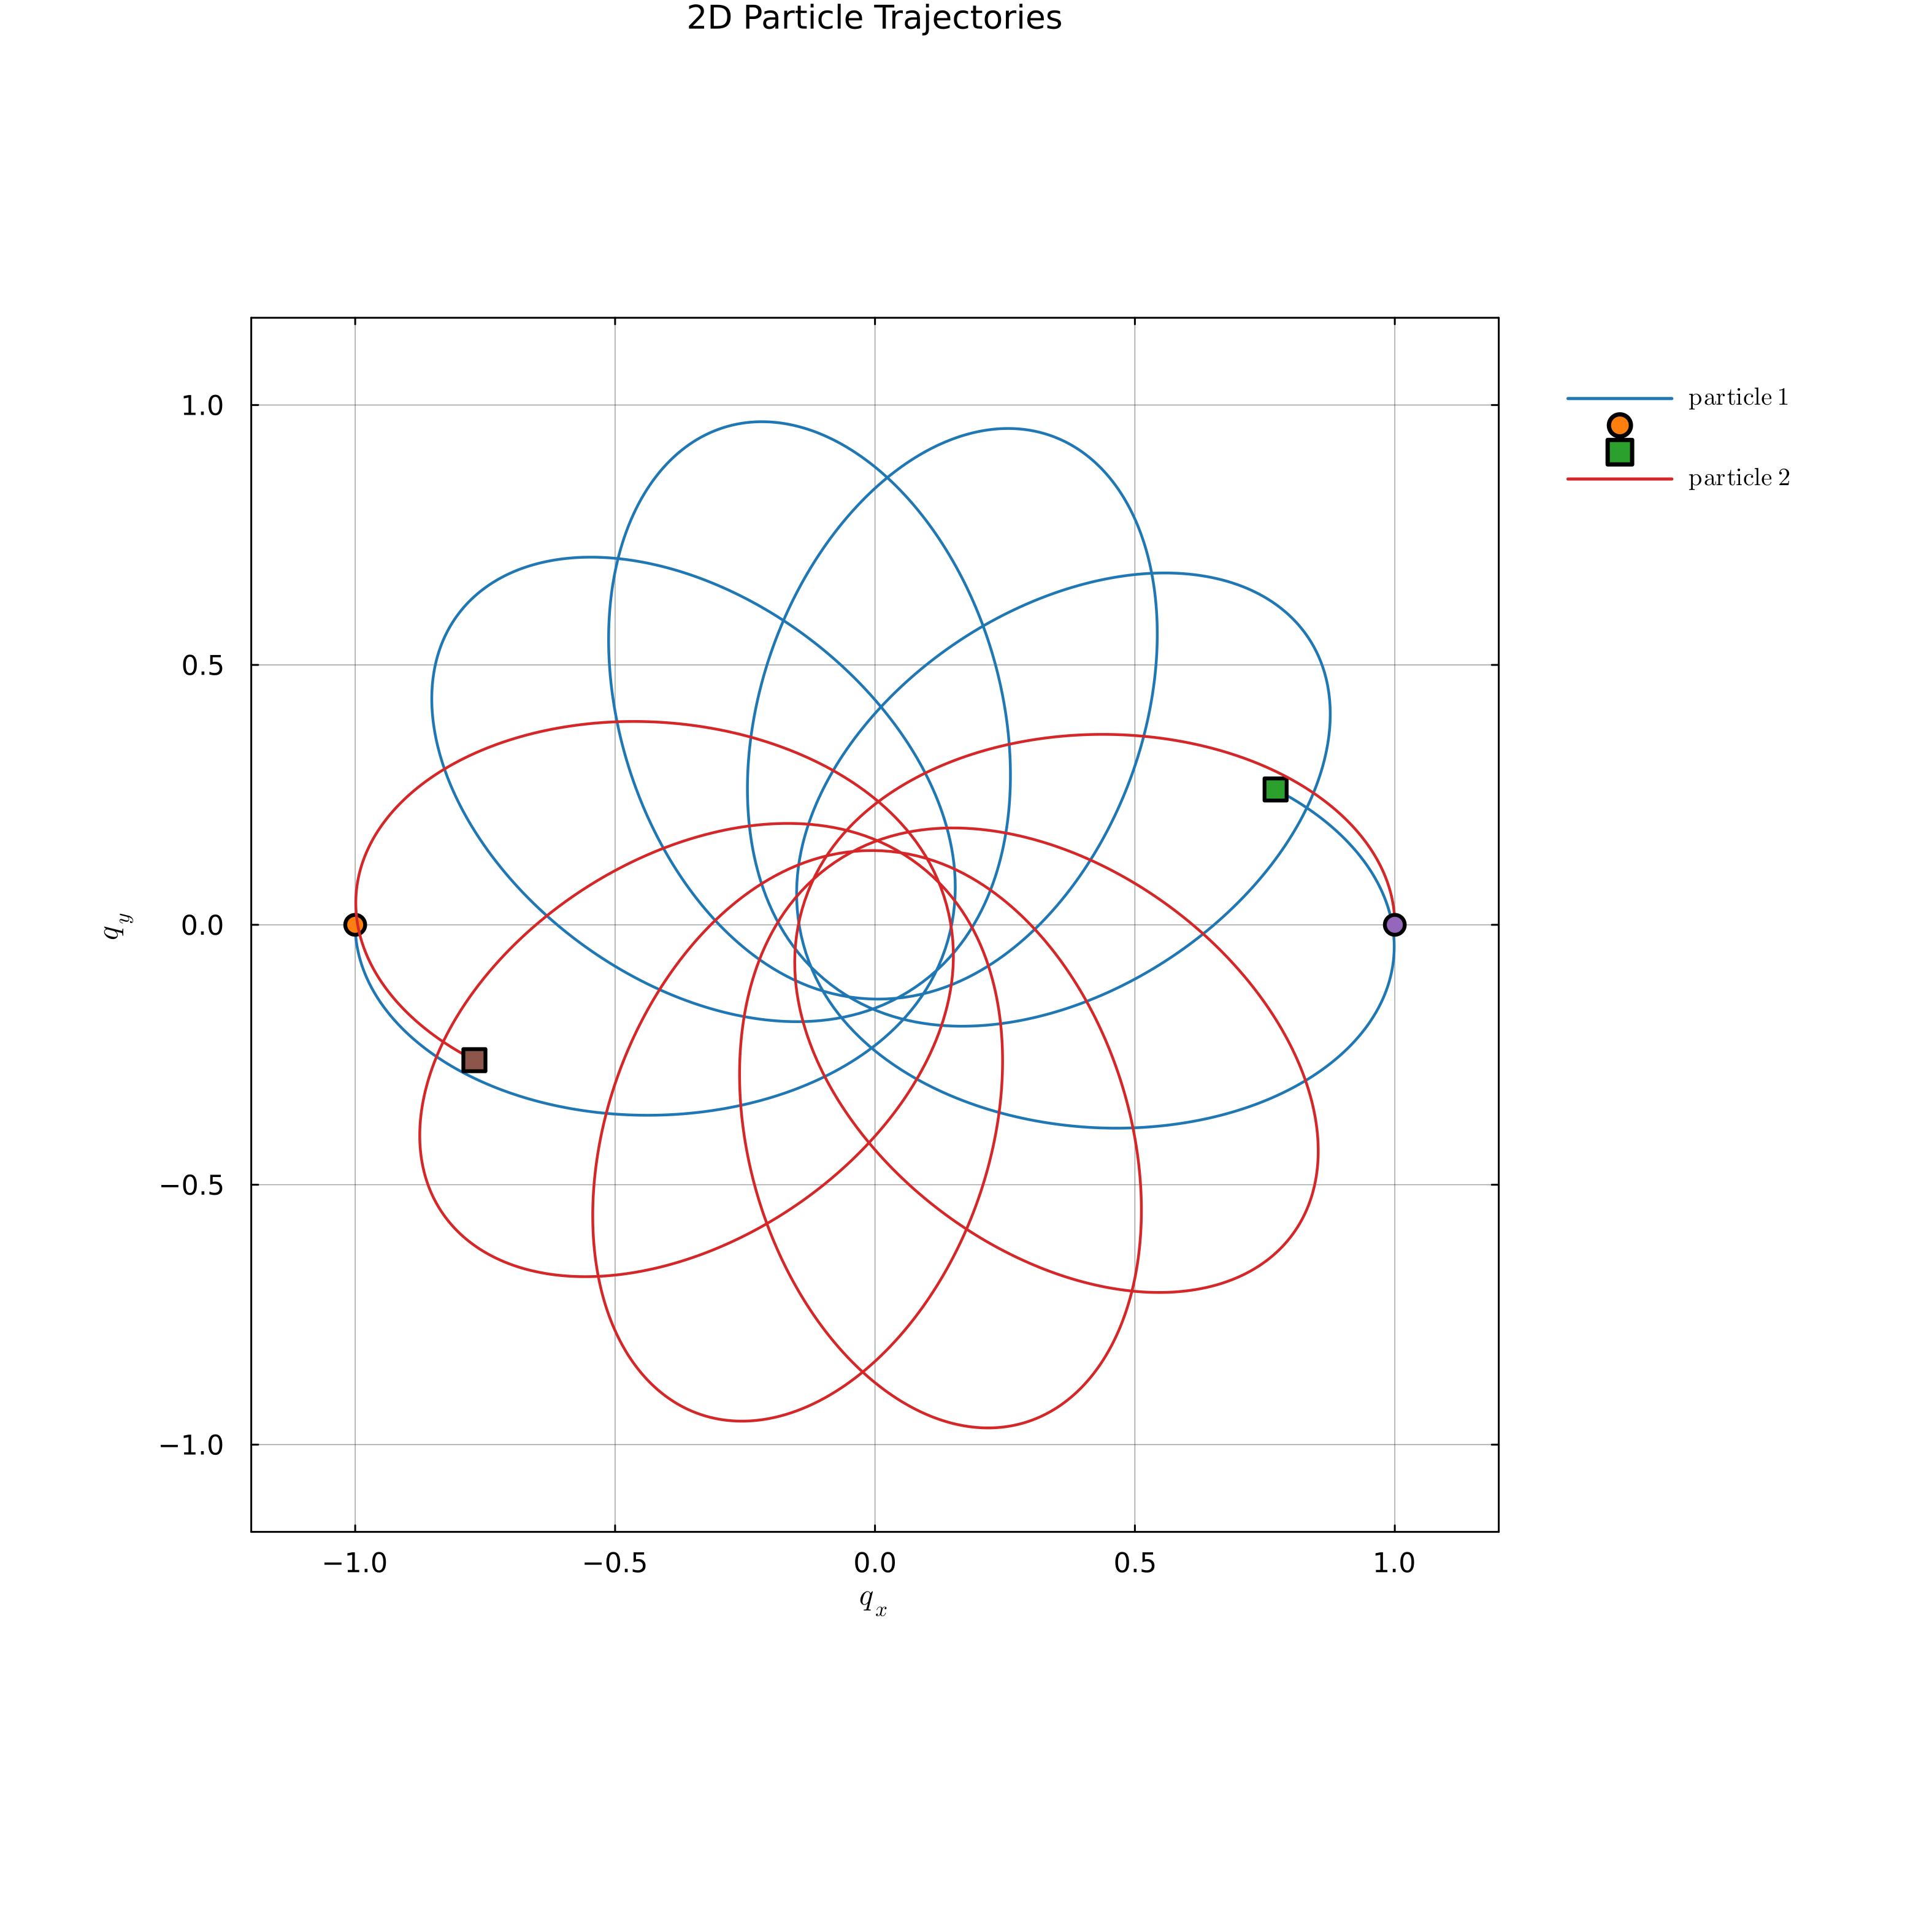

ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error


In [5]:
plot_trajectories(compute_trajectory_data(sol, 2, 2; stride = 10))

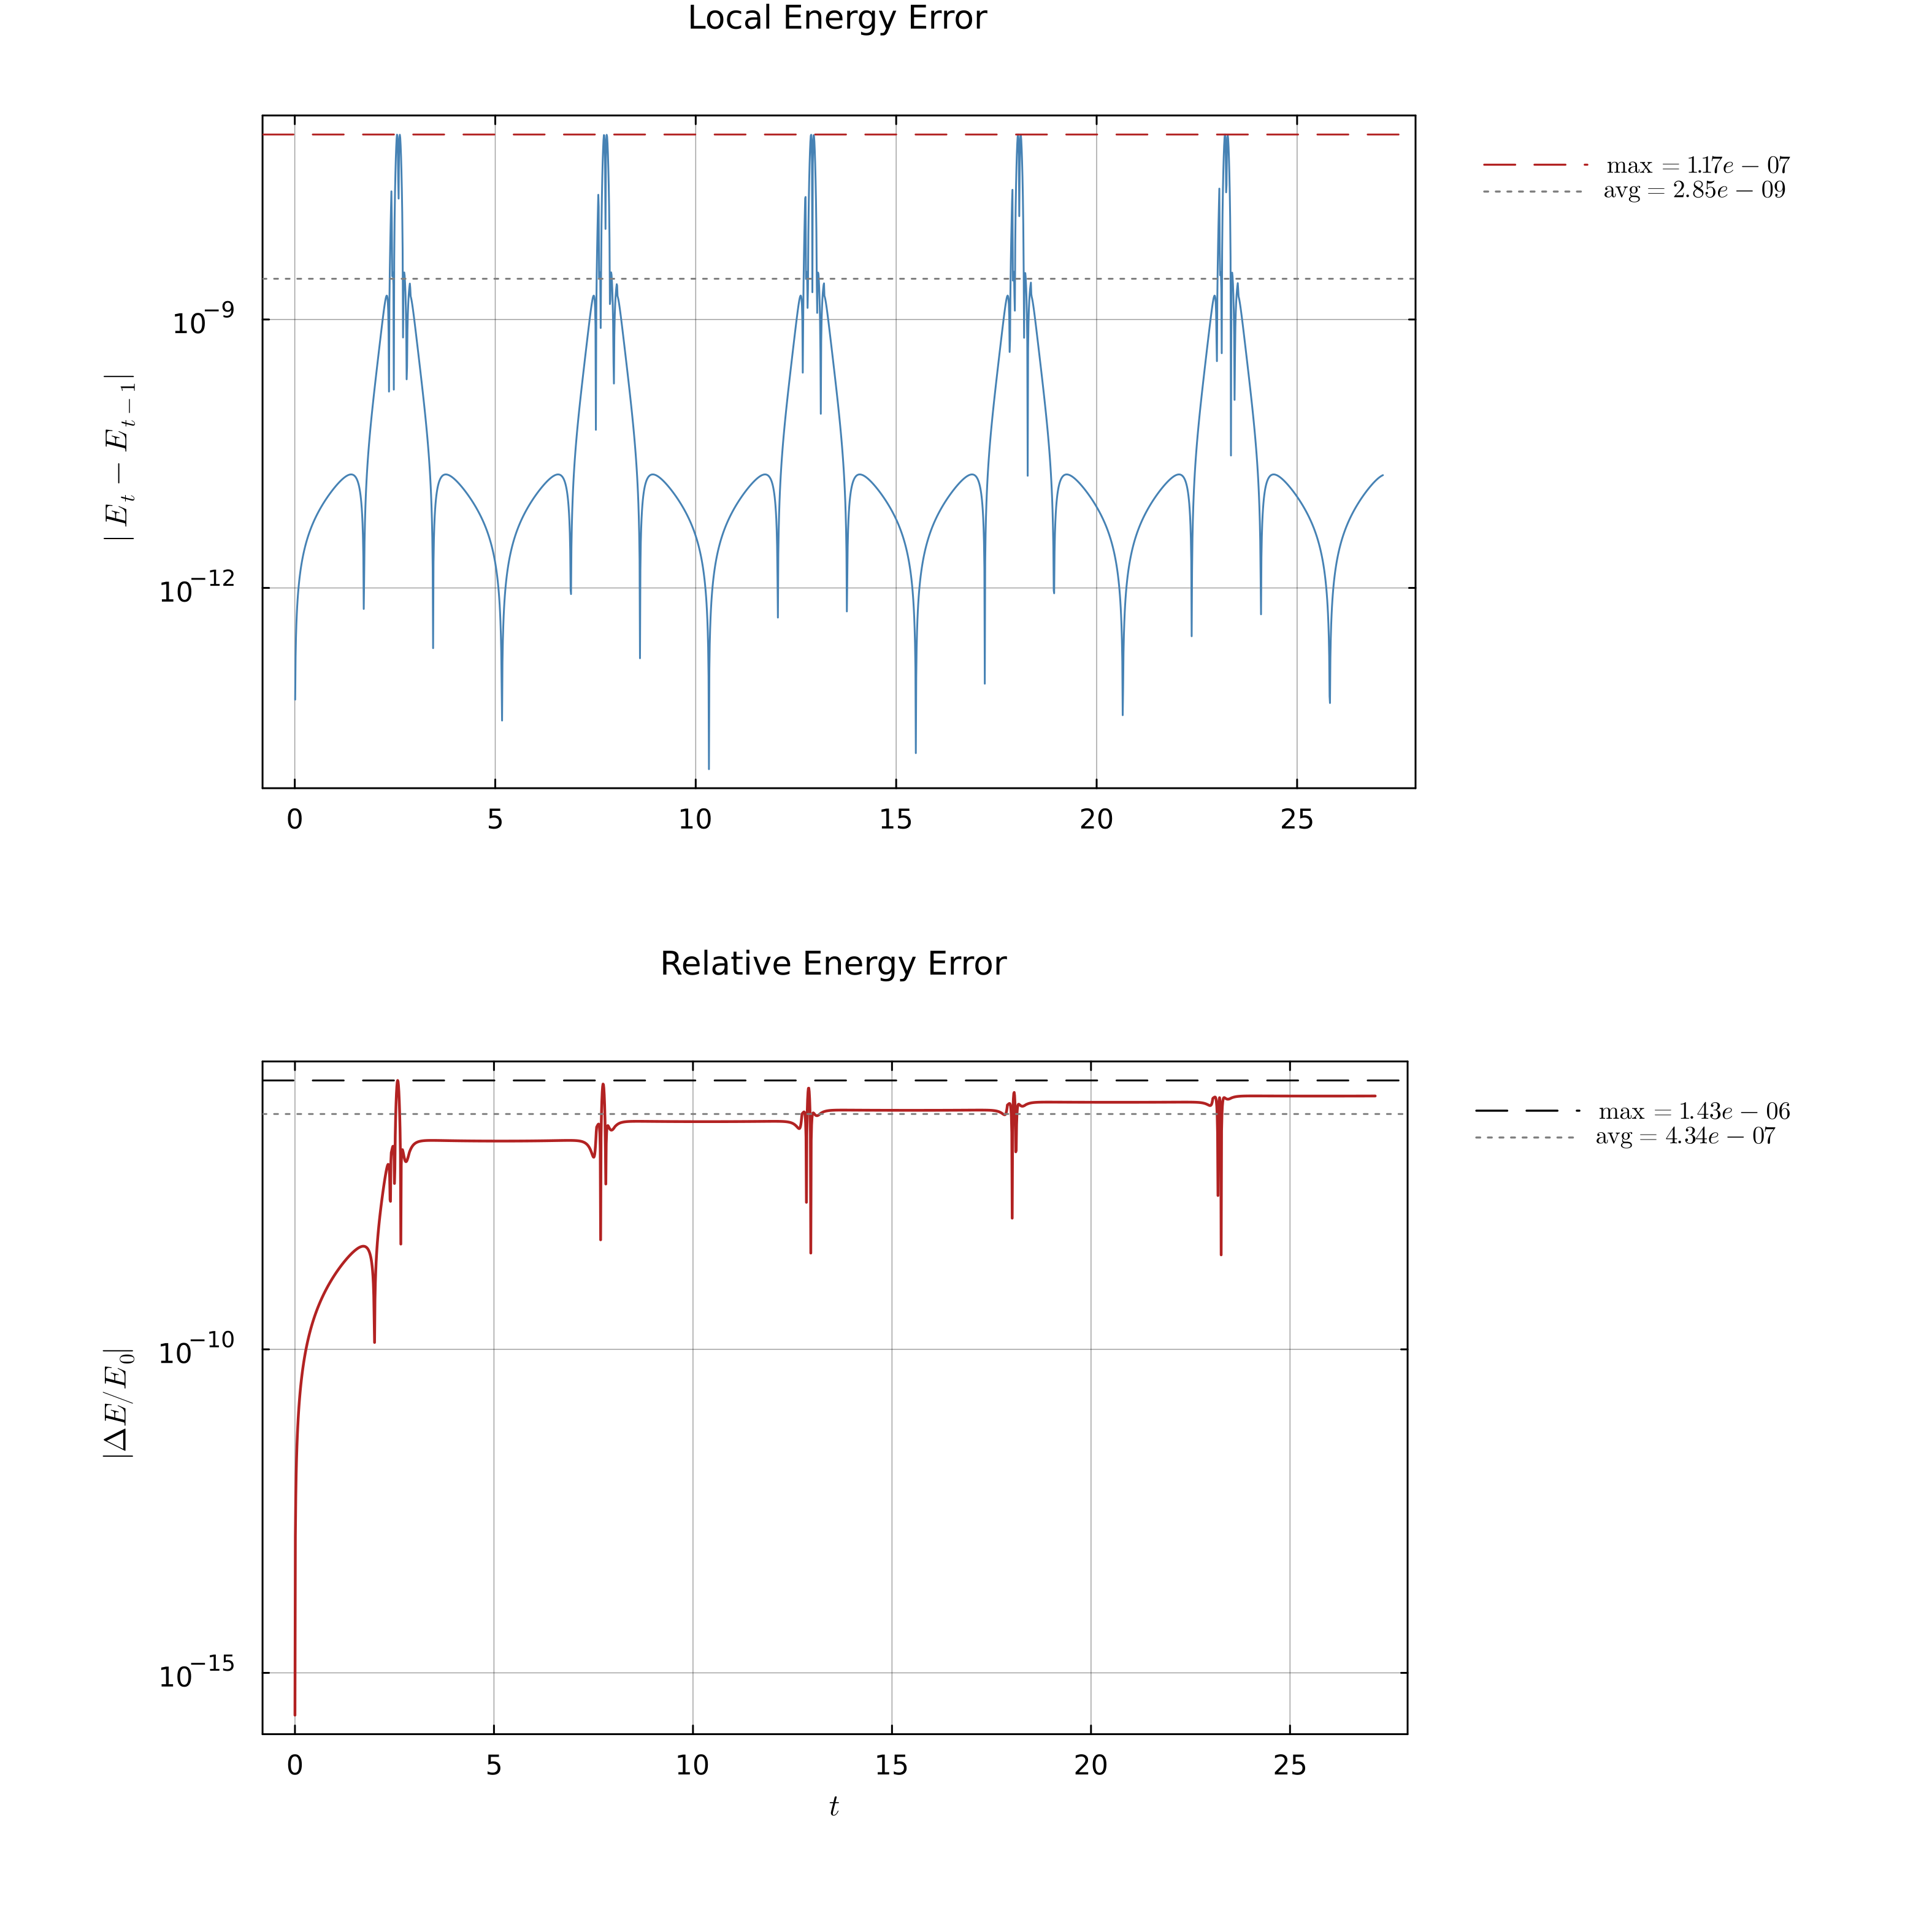

In [6]:
plot_energy_errors(compute_energy_timeseries(sol; stride = 10))

## 5. Hysteresis in action

We expect to see the mode history flip `0 → 1 → 0 → 1 → 0 → ...` five times (once per orbit) over the 5-period run, with each `1`-block covering the periapsis window defined by `r_on = 0.5` and `r_off = 0.7`. The count of `1`s divided by five is roughly the number of steps per periapsis passage.

In [7]:
runs = Int[]
prev = UInt8(255)
for m in mode_hist
    if m != prev && m == UInt8(1)
        push!(runs, 1)
    elseif m == UInt8(1) && !isempty(runs)
        runs[end] += 1
    end
    prev = m
end

println("Periapsis-passage mode-1 runs detected: ", length(runs))
println("Run lengths (steps): ", runs)

Periapsis-passage mode-1 runs detected: 5
Run lengths (steps): [462, 462, 462, 462, 463]
[462, 462, 462, 462, 463]
